# 🎯 Logistic Regression — Interactive Lecture Notebook
## TTK4260: Multivariate Data Analysis & Machine Learning

**Instructor:** Adil Rasheed — Department of Engineering Cybernetics, NTNU  
**Semester:** Spring 2026

---

### 📚 Learning Objectives

After completing this notebook, you will be able to:

1. ✅ Explain **why linear regression is unsuitable** for classification tasks
2. ✅ Describe the **sigmoid function** and its key properties
3. ✅ Derive the **binary cross-entropy loss** from Maximum Likelihood Estimation
4. ✅ Compute the **gradient** of the logistic regression cost function
5. ✅ Implement **gradient descent** for logistic regression from scratch
6. ✅ Visualize **decision boundaries** and probability landscapes
7. ✅ Evaluate classifiers using **confusion matrix**, **precision/recall**, **ROC/AUC**
8. ✅ Apply **L1 (Lasso) and L2 (Ridge) regularization** to logistic regression
9. ✅ Extend binary classification to **multiclass** via One-vs-Rest and Softmax
10. ✅ Understand **nonlinear decision boundaries** through feature engineering

---

### 📋 Prerequisites

| Topic | What You Need |
|-------|---------------|
| Linear Algebra | Vectors, matrices, dot products |
| Calculus | Partial derivatives, chain rule |
| Probability | Bernoulli distribution, likelihood |
| Prior Lectures | Linear Regression, MLE, Performance Metrics |

---

### 📖 Table of Contents

1. [Setup & Imports](#setup)
2. [Motivation & Problem Setup](#motivation)
3. [The Sigmoid Function](#sigmoid)
4. [Maximum Likelihood & The Cost Function](#mle)
5. [Gradient Descent & Optimization](#gradient)
6. [Decision Boundaries & Geometry](#boundaries)
7. [Model Evaluation](#evaluation)
8. [Regularization](#regularization)
9. [Multiclass Logistic Regression](#multiclass)
10. [Nonlinear Decision Boundaries](#nonlinear)
11. [Summary & Key Takeaways](#summary)

<a id='setup'></a>
## 1. 🔧 Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.special import expit  # numerically stable sigmoid
from scipy.optimize import minimize
from sklearn.datasets import make_classification, make_circles, make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, accuracy_score, f1_score
)
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown, HBox, VBox, interactive_output, HTML
import warnings

# Style settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
warnings.filterwarnings('ignore')
np.random.seed(42)

# Color constants for consistent styling
BLUE = '#1f77b4'
RED = '#d62728'
ORANGE = '#ff7f0e'
GREEN = '#2ca02c'
PURPLE = '#9467bd'

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


### Helper Functions

Utility functions used throughout the notebook.

In [2]:
def sigmoid(z):
    """Numerically stable sigmoid function."""
    return expit(z)


def print_box(title, content, color='blue'):
    """Print a formatted box for key results."""
    colors = {'blue': '\033[94m', 'green': '\033[92m', 'red': '\033[91m', 'yellow': '\033[93m'}
    reset = '\033[0m'
    c = colors.get(color, '')
    border = '═' * (max(len(title), max(len(l) for l in content.split('\n'))) + 4)
    print(f"{c}╔{border}╗")
    print(f"║  {title.center(len(border)-4)}  ║")
    print(f"╠{border}╣")
    for line in content.split('\n'):
        print(f"║  {line.ljust(len(border)-4)}  ║")
    print(f"╚{border}╝{reset}")


def generate_binary_data(n=200, separation=2.0, seed=42):
    """Generate 2D binary classification data."""
    rng = np.random.RandomState(seed)
    n0 = n // 2
    n1 = n - n0
    X0 = rng.randn(n0, 2) + np.array([-separation / 2, -separation / 2])
    X1 = rng.randn(n1, 2) + np.array([separation / 2, separation / 2])
    X = np.vstack([X0, X1])
    y = np.hstack([np.zeros(n0), np.ones(n1)])
    return X, y


def plot_decision_boundary(X, y, model_predict, ax=None, title='Decision Boundary',
                           resolution=200, alpha=0.3):
    """Plot decision boundary for a 2D classifier."""
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(7, 5))
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, resolution),
                         np.linspace(y_min, y_max, resolution))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model_predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=np.linspace(0, 1, 50), cmap='RdBu', alpha=alpha)
    ax.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2, linestyles='--')
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', edgecolors='k',
                         s=40, linewidths=0.5, vmin=0, vmax=1)
    ax.set_xlabel('$x_1$', fontsize=12)
    ax.set_ylabel('$x_2$', fontsize=12)
    ax.set_title(title, fontsize=14)
    return ax


print('✅ Helper functions defined.')

✅ Helper functions defined.


<a id='motivation'></a>
## 2. 💡 Motivation & Problem Setup

### From Regression to Classification

In **linear regression**, we predict a continuous value $\hat{y} \in \mathbb{R}$. But many real-world problems require a **categorical** answer:

| Domain | Question | Type |
|--------|----------|------|
| Email | Spam or not? | Binary |
| Medical | Healthy or diseased? | Binary |
| Industrial | Sensor fault: yes or no? | Binary |
| Maritime | Ship collision risk? | Binary |

**Key Question:** Can we adapt the linear model $z = \boldsymbol{\theta}^\top \boldsymbol{x} + \theta_0$ so that its output represents a **probability** $\in [0, 1]$?

---

### 🏭 Scenario: Sensor Fault Detection

A process plant logs **pressure** and **temperature** from a reactor vessel. Historical data is labelled *normal* or *fault*. When a new reading arrives, we need to answer:

> **Normal or fault? And how confident are we?**

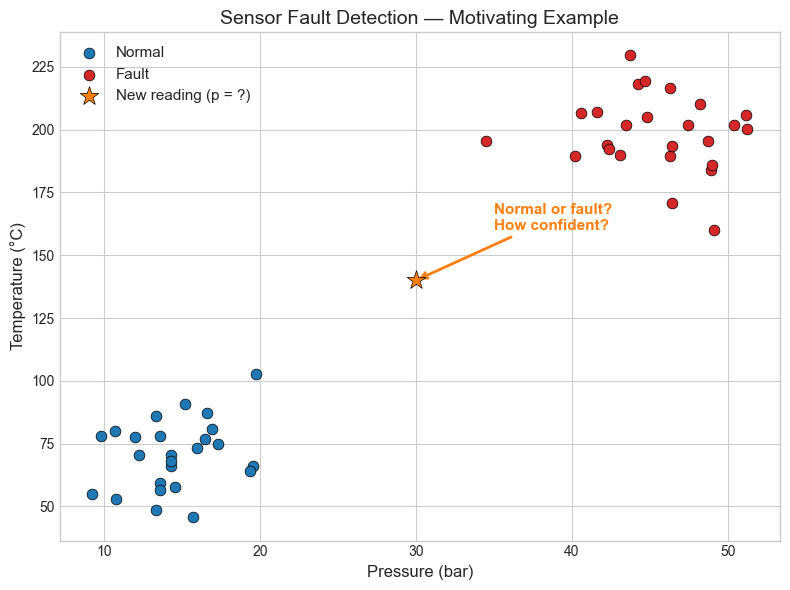

In [3]:
# Scenario: Sensor Fault Detection
np.random.seed(42)

# Generate normal readings (lower pressure, lower temperature)
n_normal = 25
pressure_normal = np.random.normal(15, 3, n_normal)
temp_normal = np.random.normal(75, 15, n_normal)

# Generate fault readings (higher pressure, higher temperature)
n_fault = 25
pressure_fault = np.random.normal(45, 4, n_fault)
temp_fault = np.random.normal(200, 20, n_fault)

# New query point
query_pressure = 30
query_temp = 140

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(pressure_normal, temp_normal, c=BLUE, s=60, label='Normal', edgecolors='k', linewidths=0.5)
ax.scatter(pressure_fault, temp_fault, c=RED, s=60, label='Fault', edgecolors='k', linewidths=0.5)
ax.scatter(query_pressure, query_temp, c=ORANGE, s=200, marker='*', zorder=5, edgecolors='k',
           linewidths=0.5, label='New reading (p = ?)')
ax.annotate('Normal or fault?\nHow confident?', xy=(query_pressure, query_temp),
            xytext=(query_pressure + 5, query_temp + 20),
            fontsize=11, fontweight='bold', color=ORANGE,
            arrowprops=dict(arrowstyle='->', color=ORANGE, lw=2))
ax.set_xlabel('Pressure (bar)', fontsize=12)
ax.set_ylabel('Temperature (°C)', fontsize=12)
ax.set_title('Sensor Fault Detection — Motivating Example', fontsize=14)
ax.legend(fontsize=11, loc='upper left')
plt.tight_layout()
plt.show()

### ⚠️ Why Not Linear Regression for Classification?

Three fundamental problems arise when applying linear regression to classification:

| Problem | Description |
|---------|-------------|
| **Unbounded Output** | Linear model gives $\hat{y} \in (-\infty, +\infty)$, but we need $\hat{y} \in [0, 1]$ for valid probabilities |
| **Outlier Sensitivity** | A single far-away point can shift the decision boundary dramatically |
| **Wrong Loss Surface** | MSE with a sigmoid is **non-convex** — gradient descent gets stuck in bad local minima |

Let's see this visually:

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


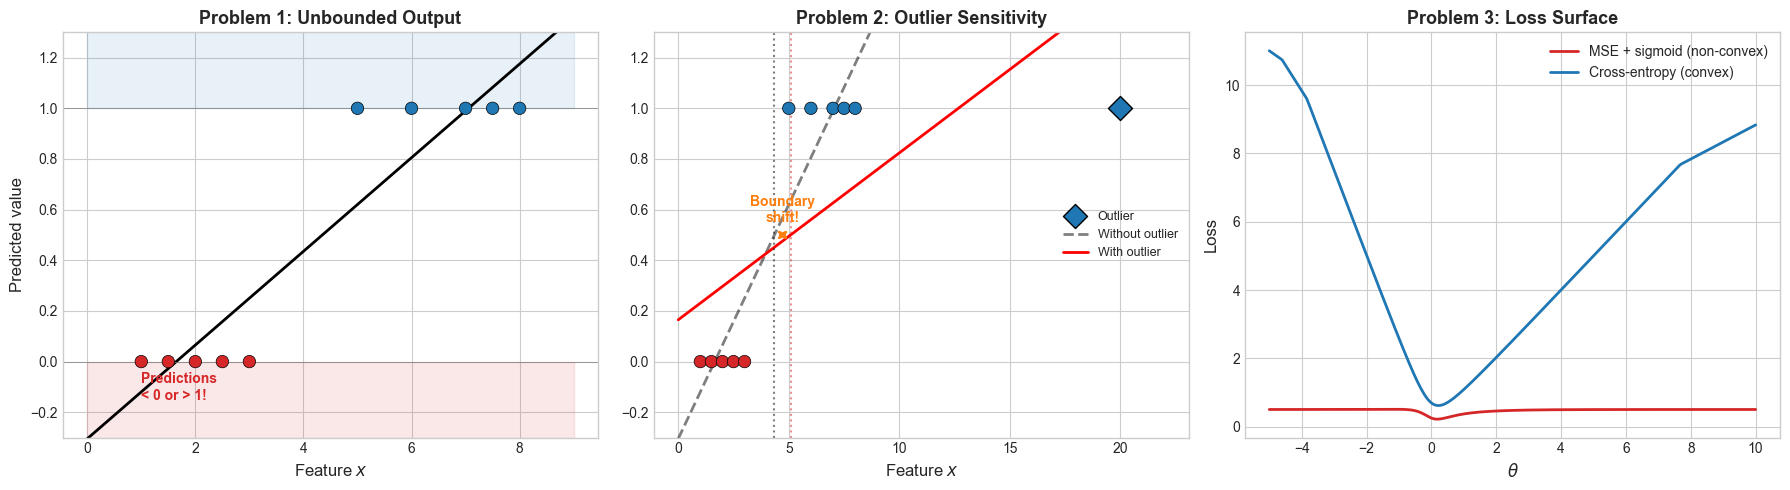

╔══════════════════════════════════════════════════════════════════╗
║                             Solution                             ║
╠══════════════════════════════════════════════════════════════════╣
║  Apply a nonlinear transformation σ(z) that squashes ℝ → (0, 1)  ║
╚══════════════════════════════════════════════════════════════════╝


In [4]:
# Demonstrate why linear regression fails for classification
np.random.seed(7)
x_class = np.array([1, 1.5, 2, 2.5, 3, 5, 6, 7, 7.5, 8])
y_class = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel 1: Linear regression on binary labels ---
from numpy.polynomial.polynomial import polyfit
coeffs = np.polyfit(x_class, y_class, 1)
x_line = np.linspace(0, 9, 200)
y_line = np.polyval(coeffs, x_line)

axes[0].scatter(x_class, y_class, c=[RED if y == 0 else BLUE for y in y_class],
                s=80, edgecolors='k', linewidths=0.5, zorder=5)
axes[0].plot(x_line, y_line, 'k-', lw=2, label='Linear fit')
axes[0].axhline(0, color='gray', lw=0.5)
axes[0].axhline(1, color='gray', lw=0.5)
axes[0].fill_between(x_line, -0.3, 0, alpha=0.1, color=RED)
axes[0].fill_between(x_line, 1, 1.3, alpha=0.1, color=BLUE)
axes[0].set_ylim(-0.3, 1.3)
axes[0].set_xlabel('Feature $x$', fontsize=12)
axes[0].set_ylabel('Predicted value', fontsize=12)
axes[0].set_title('Problem 1: Unbounded Output', fontsize=13, fontweight='bold')
axes[0].annotate('Predictions\n< 0 or > 1!', xy=(1, -0.15), fontsize=10, color=RED,
                 fontweight='bold')

# --- Panel 2: Outlier sensitivity ---
x_outlier = np.append(x_class, 20)  # extreme outlier
y_outlier = np.append(y_class, 1)
coeffs_no = np.polyfit(x_class, y_class, 1)
coeffs_out = np.polyfit(x_outlier, y_outlier, 1)
x_ext = np.linspace(0, 22, 200)

axes[1].scatter(x_class, y_class, c=[RED if y == 0 else BLUE for y in y_class],
                s=80, edgecolors='k', linewidths=0.5, zorder=5)
axes[1].scatter(20, 1, c=BLUE, s=150, marker='D', edgecolors='k', zorder=5, label='Outlier')
axes[1].plot(x_ext, np.polyval(coeffs_no, x_ext), 'k--', lw=2, alpha=0.5, label='Without outlier')
axes[1].plot(x_ext, np.polyval(coeffs_out, x_ext), 'r-', lw=2, label='With outlier')
# Mark the threshold shift
thresh_no = -coeffs_no[1] / coeffs_no[0] + 0.5 / coeffs_no[0]
thresh_out = -coeffs_out[1] / coeffs_out[0] + 0.5 / coeffs_out[0]
axes[1].axvline(thresh_no, color='k', ls=':', alpha=0.5)
axes[1].axvline(thresh_out, color=RED, ls=':', alpha=0.5)
axes[1].annotate('', xy=(thresh_out, 0.5), xytext=(thresh_no, 0.5),
                 arrowprops=dict(arrowstyle='<->', color=ORANGE, lw=2))
axes[1].text((thresh_no + thresh_out) / 2, 0.55, 'Boundary\nshift!',
             ha='center', fontsize=10, color=ORANGE, fontweight='bold')
axes[1].set_ylim(-0.3, 1.3)
axes[1].set_xlabel('Feature $x$', fontsize=12)
axes[1].set_title('Problem 2: Outlier Sensitivity', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9, loc='center right')

# --- Panel 3: Non-convex loss ---
theta_range = np.linspace(-5, 10, 300)
# MSE loss with sigmoid: non-convex
x_simple = np.array([1, 2, 3, 4, 5, 6])
y_simple = np.array([0, 0, 0, 1, 1, 1])
mse_loss = np.array([np.mean((sigmoid(t * x_simple) - y_simple) ** 2) for t in theta_range])
# Cross-entropy loss: convex
def cross_entropy_1d(t):
    p = sigmoid(t * x_simple)
    p = np.clip(p, 1e-10, 1 - 1e-10)
    return -np.mean(y_simple * np.log(p) + (1 - y_simple) * np.log(1 - p))

ce_loss = np.array([cross_entropy_1d(t) for t in theta_range])

axes[2].plot(theta_range, mse_loss, c=RED, lw=2, label='MSE + sigmoid (non-convex)')
axes[2].plot(theta_range, ce_loss, c=BLUE, lw=2, label='Cross-entropy (convex)')
axes[2].set_xlabel('$\\theta$', fontsize=12)
axes[2].set_ylabel('Loss', fontsize=12)
axes[2].set_title('Problem 3: Loss Surface', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.show()

print_box('Solution', 'Apply a nonlinear transformation σ(z) that squashes ℝ → (0, 1)', 'green')

<a id='sigmoid'></a>
## 3. 📈 The Sigmoid (Logistic) Function

### Definition

$$
\sigma(z) = \frac{1}{1 + e^{-z}}, \qquad z = \boldsymbol{\theta}^\top \boldsymbol{x} + \theta_0
$$

### Key Properties

| Property | Value |
|----------|-------|
| $\sigma(z) \to 0$ | as $z \to -\infty$ |
| $\sigma(z) \to 1$ | as $z \to +\infty$ |
| $\sigma(0) = 0.5$ | decision threshold |
| Monotonically increasing | always |
| **Elegant derivative** | $\sigma'(z) = \sigma(z)\bigl(1 - \sigma(z)\bigr)$ |

In [5]:
# Interactive sigmoid function explorer
def plot_sigmoid_interactive(scale=1.0, shift=0.0):
    z = np.linspace(-8, 8, 500)
    sig = sigmoid(scale * (z - shift))
    sig_deriv = scale * sig * (1 - sig)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Sigmoid
    ax = axes[0]
    ax.plot(z, sigmoid(z), 'k--', alpha=0.3, lw=1, label='$\\sigma(z)$ (default)')
    ax.plot(z, sig, c=BLUE, lw=3, label=f'$\\sigma({scale:.1f}(z-{shift:.1f}))$')
    ax.axhline(0.5, color='gray', ls=':', lw=1)
    ax.axhline(0, color='gray', ls='-', lw=0.5)
    ax.axhline(1, color='gray', ls=':', lw=1)
    ax.axvline(shift, color=ORANGE, ls='--', lw=1, alpha=0.7, label=f'Threshold at z={shift:.1f}')
    ax.fill_between(z, 0, sig, where=(sig < 0.5), alpha=0.1, color=RED)
    ax.fill_between(z, 0, sig, where=(sig >= 0.5), alpha=0.1, color=BLUE)
    ax.set_xlabel('$z$', fontsize=13)
    ax.set_ylabel('$\\sigma(z)$', fontsize=13)
    ax.set_title('Sigmoid Function', fontsize=14)
    ax.legend(fontsize=10)
    ax.set_ylim(-0.05, 1.1)
    ax.text(-7, 0.15, 'Class 0', fontsize=12, color=RED, fontweight='bold')
    ax.text(5, 0.85, 'Class 1', fontsize=12, color=BLUE, fontweight='bold')

    # Right: Derivative
    ax = axes[1]
    ax.plot(z, sig_deriv, c=GREEN, lw=3, label="$\\sigma'(z) = \\sigma(z)(1-\\sigma(z))$")
    ax.axvline(shift, color=ORANGE, ls='--', lw=1, alpha=0.7)
    ax.fill_between(z, 0, sig_deriv, alpha=0.15, color=GREEN)
    ax.set_xlabel('$z$', fontsize=13)
    ax.set_ylabel("$\\sigma'(z)$", fontsize=13)
    ax.set_title('Sigmoid Derivative', fontsize=14)
    ax.legend(fontsize=10)
    ax.annotate(f'Max = {scale/4:.2f}\nat z = {shift:.1f}',
                xy=(shift, scale / 4), xytext=(shift + 2, scale / 4 + 0.05),
                fontsize=10, arrowprops=dict(arrowstyle='->', color='k'))

    plt.tight_layout()
    plt.show()

interact(
    plot_sigmoid_interactive,
    scale=FloatSlider(value=1.0, min=0.2, max=5.0, step=0.1, description='Scale (|θ|):',
                      style={'description_width': 'initial'}),
    shift=FloatSlider(value=0.0, min=-4.0, max=4.0, step=0.2, description='Shift (θ₀):',
                      style={'description_width': 'initial'}),
);

interactive(children=(FloatSlider(value=1.0, description='Scale (|θ|):', max=5.0, min=0.2, style=SliderStyle(d…

### 📌 From Odds to Logits

The logistic regression model assumes the **log-odds** of the positive class is a **linear function** of the features:

$$
\underbrace{p}_{\text{Probability}} \;\longrightarrow\; \underbrace{\frac{p}{1-p}}_{\text{Odds}} \;\longrightarrow\; \underbrace{\log\frac{p}{1-p} = \boldsymbol{\theta}^\top\boldsymbol{x}+\theta_0}_{\text{Log-Odds (Logit)}}
$$

**Inverting the logit** gives us the sigmoid:

$$
p = \sigma(\boldsymbol{\theta}^\top\boldsymbol{x}+\theta_0)
$$

> *Analogy:* Linear regression assumes $y = \boldsymbol{\theta}^\top\boldsymbol{x}+\theta_0+\varepsilon$. Logistic regression assumes a linear relationship with the **log-odds**, not $y$ directly. This is a **Generalized Linear Model (GLM)**.

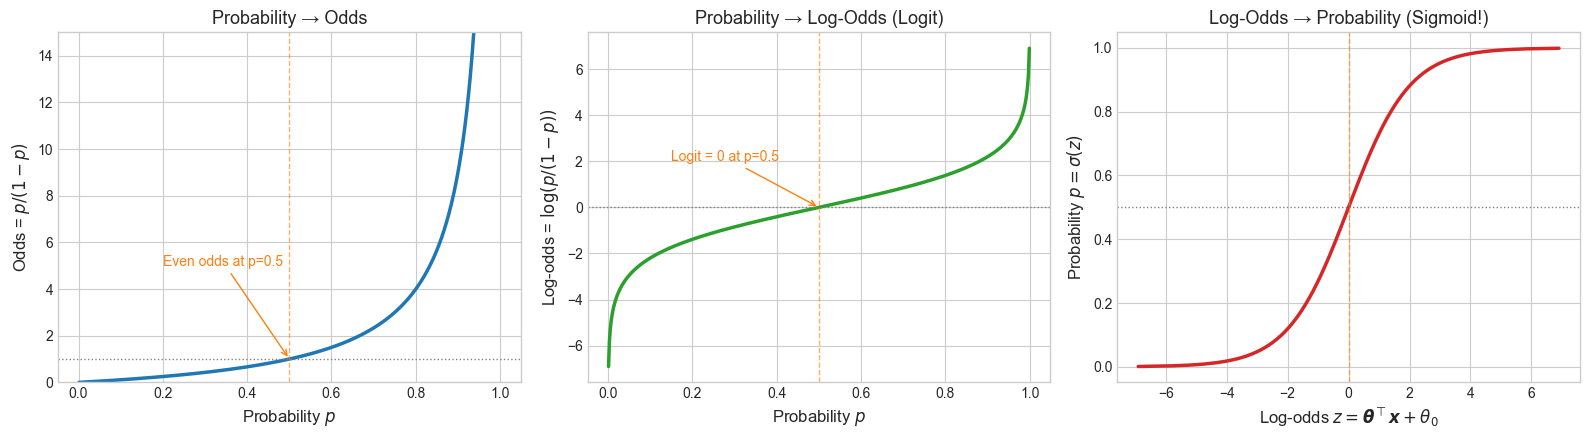

In [6]:
# Visualize the relationship: probability ↔ odds ↔ log-odds
p = np.linspace(0.001, 0.999, 500)
odds = p / (1 - p)
log_odds = np.log(odds)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Panel 1: p vs odds
axes[0].plot(p, odds, c=BLUE, lw=2.5)
axes[0].axhline(1, color='gray', ls=':', lw=1)
axes[0].axvline(0.5, color=ORANGE, ls='--', lw=1, alpha=0.6)
axes[0].set_xlabel('Probability $p$', fontsize=12)
axes[0].set_ylabel('Odds = $p / (1-p)$', fontsize=12)
axes[0].set_title('Probability → Odds', fontsize=13)
axes[0].set_ylim(0, 15)
axes[0].annotate('Even odds at p=0.5', xy=(0.5, 1), xytext=(0.2, 5),
                 arrowprops=dict(arrowstyle='->', color=ORANGE), fontsize=10, color=ORANGE)

# Panel 2: p vs log-odds
axes[1].plot(p, log_odds, c=GREEN, lw=2.5)
axes[1].axhline(0, color='gray', ls=':', lw=1)
axes[1].axvline(0.5, color=ORANGE, ls='--', lw=1, alpha=0.6)
axes[1].set_xlabel('Probability $p$', fontsize=12)
axes[1].set_ylabel('Log-odds = $\\log(p/(1-p))$', fontsize=12)
axes[1].set_title('Probability → Log-Odds (Logit)', fontsize=13)
axes[1].annotate('Logit = 0 at p=0.5', xy=(0.5, 0), xytext=(0.15, 2),
                 arrowprops=dict(arrowstyle='->', color=ORANGE), fontsize=10, color=ORANGE)

# Panel 3: log-odds vs p (this IS the sigmoid!)
axes[2].plot(log_odds, p, c=RED, lw=2.5)
axes[2].axhline(0.5, color='gray', ls=':', lw=1)
axes[2].axvline(0, color=ORANGE, ls='--', lw=1, alpha=0.6)
axes[2].set_xlabel('Log-odds $z = \\boldsymbol{\\theta}^\\top\\boldsymbol{x}+\\theta_0$', fontsize=12)
axes[2].set_ylabel('Probability $p = \\sigma(z)$', fontsize=12)
axes[2].set_title('Log-Odds → Probability (Sigmoid!)', fontsize=13)

plt.tight_layout()
plt.show()

### The Logistic Regression Model

$$
\boxed{P(y=1 \mid \boldsymbol{x};\, \boldsymbol{\theta}, \theta_0) = \sigma(\boldsymbol{\theta}^\top\boldsymbol{x}+\theta_0) = \frac{1}{1+e^{-(\boldsymbol{\theta}^\top\boldsymbol{x}+\theta_0)}}}
$$

$$
P(y=0 \mid \boldsymbol{x};\, \boldsymbol{\theta}, \theta_0) = 1 - \sigma(\boldsymbol{\theta}^\top\boldsymbol{x}+\theta_0)
$$

**Compact Bernoulli form:**

$$
P(y \mid \boldsymbol{x};\, \boldsymbol{\theta}, \theta_0) = \sigma(z)^{y} \bigl(1-\sigma(z)\bigr)^{1-y}
$$

- When $y=1$: $P = \sigma(z)$ (first factor survives)
- When $y=0$: $P = 1-\sigma(z)$ (second factor survives)

> *This compact form is essential for the likelihood derivation.*

### Notation Convention

**Absorbed-bias notation:** Define $\tilde{\boldsymbol{x}} = [1, x_1, x_2, \ldots, x_p]^\top$ and $\tilde{\boldsymbol{\theta}} = [\theta_0, \theta_1, \ldots, \theta_p]^\top$.

Then: $z = \boldsymbol{\theta}^\top\boldsymbol{x} + \theta_0 = \tilde{\boldsymbol{\theta}}^{\,\top}\tilde{\boldsymbol{x}}$ (a single dot product)

| Entity | Style | Example |
|--------|-------|---------|
| Scalar | italic, lowercase | $z$, $y$, $\theta_j$ |
| Vector | bold, italic, lowercase | $\boldsymbol{x}$, $\boldsymbol{\theta}$, $\boldsymbol{y}$ |
| Matrix | bold, upright, uppercase | $\mathbf{X}$, $\mathbf{H}$ |

<a id='mle'></a>
## 4. 📊 Maximum Likelihood Estimation & The Cost Function

*You already know MLE — now we apply it to classification.*

### Step 1: Likelihood (assuming i.i.d. observations)

$$
L(\boldsymbol{\theta}, \theta_0) = \prod_{i=1}^{n} P(y_i \mid \boldsymbol{x}_i;\, \boldsymbol{\theta}, \theta_0) = \prod_{i=1}^{n} \sigma(z_i)^{y_i}\bigl(1-\sigma(z_i)\bigr)^{1-y_i}
$$

### Step 2: Log-likelihood

$$
\ell(\boldsymbol{\theta}, \theta_0) = \sum_{i=1}^{n}\Bigl[y_i\log\sigma(z_i) + (1-y_i)\log\bigl(1-\sigma(z_i)\bigr)\Bigr]
$$

### Step 3: Negative log-likelihood → our loss function (minimize!)

$$
\boxed{J(\boldsymbol{\theta}, \theta_0) = -\frac{1}{n}\sum_{i=1}^{n}\Bigl[y_i\log\sigma(z_i) + (1-y_i)\log\bigl(1-\sigma(z_i)\bigr)\Bigr]}
$$

> **Compare:** MLE with Gaussian noise ⇒ MSE (linear regression). MLE with Bernoulli ⇒ cross-entropy (logistic regression). Same principle, different distributions!

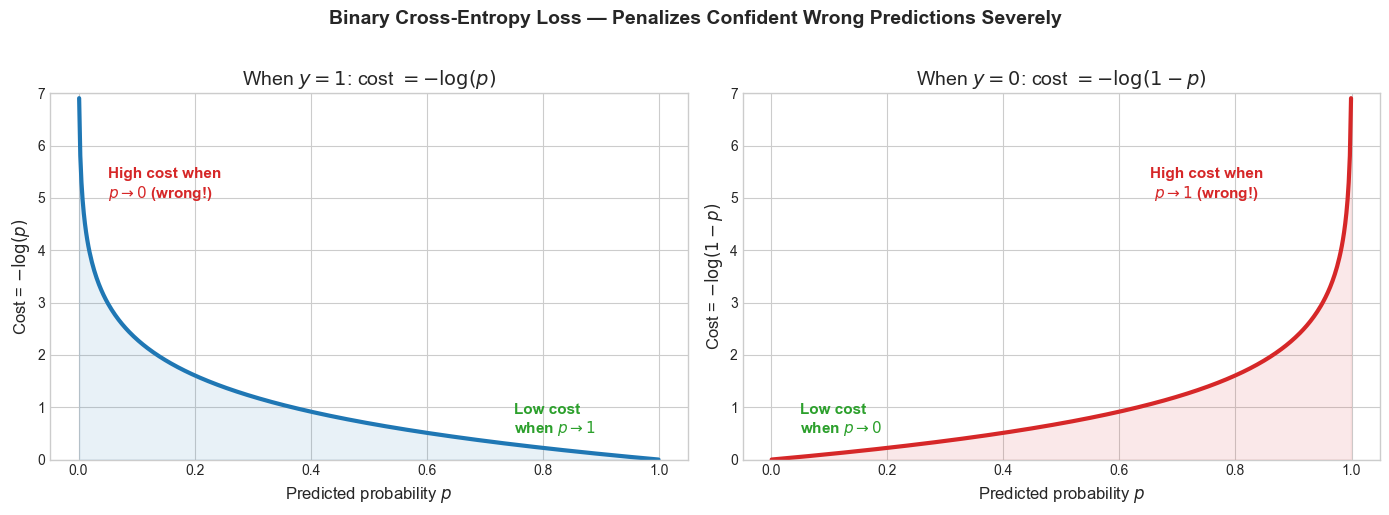

In [7]:
# Binary cross-entropy loss intuition
def plot_bce_intuition(y_true=1):
    p = np.linspace(0.001, 0.999, 500)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Loss when y=1
    loss_y1 = -np.log(p)
    axes[0].plot(p, loss_y1, c=BLUE, lw=3)
    axes[0].fill_between(p, 0, loss_y1, alpha=0.1, color=BLUE)
    axes[0].set_xlabel('Predicted probability $p$', fontsize=12)
    axes[0].set_ylabel('Cost = $-\\log(p)$', fontsize=12)
    axes[0].set_title('When $y=1$: cost $= -\\log(p)$', fontsize=14)
    axes[0].set_ylim(0, 7)
    axes[0].annotate('High cost when\n$p \\to 0$ (wrong!)', xy=(0.05, 5), fontsize=11,
                     color=RED, fontweight='bold')
    axes[0].annotate('Low cost\nwhen $p \\to 1$', xy=(0.75, 0.5), fontsize=11,
                     color=GREEN, fontweight='bold')

    # Right: Loss when y=0
    loss_y0 = -np.log(1 - p)
    axes[1].plot(p, loss_y0, c=RED, lw=3)
    axes[1].fill_between(p, 0, loss_y0, alpha=0.1, color=RED)
    axes[1].set_xlabel('Predicted probability $p$', fontsize=12)
    axes[1].set_ylabel('Cost = $-\\log(1-p)$', fontsize=12)
    axes[1].set_title('When $y=0$: cost $= -\\log(1-p)$', fontsize=14)
    axes[1].set_ylim(0, 7)
    axes[1].annotate('High cost when\n$p \\to 1$ (wrong!)', xy=(0.75, 5), fontsize=11,
                     color=RED, fontweight='bold', ha='center')
    axes[1].annotate('Low cost\nwhen $p \\to 0$', xy=(0.05, 0.5), fontsize=11,
                     color=GREEN, fontweight='bold')

    plt.suptitle('Binary Cross-Entropy Loss — Penalizes Confident Wrong Predictions Severely',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_bce_intuition()

In [8]:
# Interactive: explore how cross-entropy penalizes predictions for different true labels
def plot_bce_for_sample(p_pred=0.5, y_true=1):
    p_arr = np.linspace(0.001, 0.999, 500)
    loss = -(y_true * np.log(p_arr) + (1 - y_true) * np.log(1 - p_arr))
    p_pred_clip = np.clip(p_pred, 0.001, 0.999)
    loss_val = -(y_true * np.log(p_pred_clip) + (1 - y_true) * np.log(1 - p_pred_clip))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(p_arr, loss, c=BLUE if y_true == 1 else RED, lw=3,
            label=f'BCE loss when $y = {y_true}$')
    ax.scatter([p_pred_clip], [loss_val], c=ORANGE, s=200, zorder=5, edgecolors='k')
    ax.annotate(f'Loss = {loss_val:.3f}', xy=(p_pred_clip, loss_val),
                xytext=(p_pred_clip + 0.1, loss_val + 0.5),
                fontsize=12, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='k'))
    ax.set_xlabel('Predicted probability $p$', fontsize=12)
    ax.set_ylabel('Cross-entropy loss', fontsize=12)
    ax.set_title(f'BCE Loss for True Label $y = {y_true}$, Predicted $p = {p_pred:.2f}$', fontsize=14)
    ax.set_ylim(0, 7)
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

interact(
    plot_bce_for_sample,
    p_pred=FloatSlider(value=0.5, min=0.01, max=0.99, step=0.01, description='Predicted p:',
                       style={'description_width': 'initial'}),
    y_true=Dropdown(options=[0, 1], value=1, description='True label y:',
                    style={'description_width': 'initial'}),
);

interactive(children=(FloatSlider(value=0.5, description='Predicted p:', max=0.99, min=0.01, step=0.01, style=…

### Key Property of the Cross-Entropy Loss

- The loss penalizes **confident wrong predictions** severely (cost → ∞)
- The cross-entropy loss is **convex** in $(\boldsymbol{\theta}, \theta_0)$ — guaranteed global optimum!

<a id='gradient'></a>
## 5. ⚙️ Gradient Descent & Optimization

### Gradient of the Loss Function

Using the chain rule and $\sigma'(z) = \sigma(z)(1 - \sigma(z))$:

**Per-parameter gradient:**

$$
\frac{\partial J}{\partial \theta_j} = \frac{1}{n}\sum_{i=1}^{n}\bigl(\sigma(z_i) - y_i\bigr) x_{ij}
\qquad\qquad
\frac{\partial J}{\partial \theta_0} = \frac{1}{n}\sum_{i=1}^{n}\bigl(\sigma(z_i) - y_i\bigr)
$$

**Vector form:**

$$
\boxed{\nabla_{\boldsymbol{\theta}} J = \frac{1}{n}\, \mathbf{X}^\top\!\bigl(\sigma(\mathbf{X}\boldsymbol{\theta}+\theta_0\,\boldsymbol{1})-\boldsymbol{y}\bigr)}
$$

---

### Gradient Derivation (Step by Step)

Start from the loss for a single sample ($z_i = \boldsymbol{\theta}^\top\boldsymbol{x}_i + \theta_0$):

$$
J_i = -\bigl[y_i\log\sigma(z_i) + (1-y_i)\log(1-\sigma(z_i))\bigr]
$$

Apply the **chain rule**: $\frac{\partial J_i}{\partial \theta_j} = \frac{\partial J_i}{\partial \sigma} \cdot \frac{\partial \sigma}{\partial z_i} \cdot \frac{\partial z_i}{\partial \theta_j}$

| Factor 1 | Factor 2 | Factor 3 |
|----------|----------|----------|
| $\frac{\partial J_i}{\partial \sigma} = -\frac{y_i}{\sigma} + \frac{1-y_i}{1-\sigma}$ | $\frac{\partial \sigma}{\partial z_i} = \sigma(1-\sigma)$ | $\frac{\partial z_i}{\partial \theta_j} = x_{ij}$ |

Multiply and simplify (the $\sigma(1-\sigma)$ cancels elegantly):

$$
\frac{\partial J_i}{\partial \theta_j} = \bigl(\sigma(z_i) - y_i\bigr) x_{ij}
\qquad\Longrightarrow\qquad
\nabla_{\boldsymbol{\theta}}J = \frac{1}{n}\, \mathbf{X}^\top(\hat{\boldsymbol{p}} - \boldsymbol{y})
$$

### Remarkable Similarity to Linear Regression!

| Method | Gradient |
|--------|----------|
| Linear regression | $\nabla_{\boldsymbol{\theta}} J = \frac{1}{n}\,\mathbf{X}^\top(\mathbf{X}\boldsymbol{\theta}-\boldsymbol{y})$ |
| Logistic regression | $\nabla_{\boldsymbol{\theta}} J = \frac{1}{n}\,\mathbf{X}^\top\bigl(\sigma(\mathbf{X}\boldsymbol{\theta}+\theta_0\,\boldsymbol{1})-\boldsymbol{y}\bigr)$ |

*Same form — the only difference is $\sigma(\cdot)$ applied to the linear prediction!*

In [9]:
# ============================================================
# Logistic Regression from scratch using gradient descent
# ============================================================

class LogisticRegressionScratch:
    """Logistic regression implemented from scratch with gradient descent."""

    def __init__(self, learning_rate=0.1, n_iterations=1000, regularization=None, lam=0.01):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.regularization = regularization  # None, 'l1', or 'l2'
        self.lam = lam
        self.theta = None
        self.theta0 = None
        self.loss_history = []

    def _compute_loss(self, X, y):
        n = len(y)
        z = X @ self.theta + self.theta0
        p = sigmoid(z)
        p = np.clip(p, 1e-10, 1 - 1e-10)
        bce = -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))
        # Add regularization term
        if self.regularization == 'l2':
            bce += self.lam * np.sum(self.theta ** 2)
        elif self.regularization == 'l1':
            bce += self.lam * np.sum(np.abs(self.theta))
        return bce

    def fit(self, X, y):
        n, p = X.shape
        self.theta = np.zeros(p)
        self.theta0 = 0.0
        self.loss_history = []

        for i in range(self.n_iter):
            # Forward pass
            z = X @ self.theta + self.theta0
            p_hat = sigmoid(z)

            # Compute gradients
            error = p_hat - y
            grad_theta = (1 / n) * (X.T @ error)
            grad_theta0 = (1 / n) * np.sum(error)

            # Add regularization gradient
            if self.regularization == 'l2':
                grad_theta += 2 * self.lam * self.theta
            elif self.regularization == 'l1':
                grad_theta += self.lam * np.sign(self.theta)

            # Update parameters
            self.theta -= self.lr * grad_theta
            self.theta0 -= self.lr * grad_theta0

            self.loss_history.append(self._compute_loss(X, y))

        return self

    def predict_proba(self, X):
        return sigmoid(X @ self.theta + self.theta0)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


print('✅ LogisticRegressionScratch class defined.')

✅ LogisticRegressionScratch class defined.


In [10]:
# Interactive gradient descent visualization
X_demo, y_demo = generate_binary_data(n=200, separation=2.5, seed=42)
scaler_demo = StandardScaler()
X_demo_sc = scaler_demo.fit_transform(X_demo)


def plot_gradient_descent(learning_rate=0.5, n_iterations=50):
    model = LogisticRegressionScratch(learning_rate=learning_rate, n_iterations=n_iterations)
    model.fit(X_demo_sc, y_demo)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

    # Left: Decision boundary
    ax = axes[0]
    plot_decision_boundary(X_demo_sc, y_demo, model.predict_proba, ax=ax,
                           title=f'Decision Boundary (iter={n_iterations}, α={learning_rate})')
    # Draw the decision boundary line explicitly
    if abs(model.theta[1]) > 1e-8:
        x1_range = np.linspace(X_demo_sc[:, 0].min() - 1, X_demo_sc[:, 0].max() + 1, 100)
        x2_boundary = -(model.theta[0] * x1_range + model.theta0) / model.theta[1]
        ax.plot(x1_range, x2_boundary, 'k--', lw=2, label='$\\theta^T x + \\theta_0 = 0$')
        ax.legend(fontsize=9)
    ax.set_xlim(X_demo_sc[:, 0].min() - 1, X_demo_sc[:, 0].max() + 1)
    ax.set_ylim(X_demo_sc[:, 1].min() - 1, X_demo_sc[:, 1].max() + 1)

    # Right: Loss curve
    ax = axes[1]
    ax.plot(model.loss_history, c=BLUE, lw=2)
    ax.set_xlabel('Iteration', fontsize=12)
    ax.set_ylabel('Cross-Entropy Loss', fontsize=12)
    ax.set_title('Training Loss Over Iterations', fontsize=14)
    ax.annotate(f'Final loss: {model.loss_history[-1]:.4f}',
                xy=(len(model.loss_history) - 1, model.loss_history[-1]),
                xytext=(len(model.loss_history) * 0.5, model.loss_history[0] * 0.7),
                fontsize=11, arrowprops=dict(arrowstyle='->', color='k'))

    # Print model info
    acc = accuracy_score(y_demo, model.predict(X_demo_sc))
    fig.text(0.5, -0.02,
             f'θ = [{model.theta[0]:.3f}, {model.theta[1]:.3f}], θ₀ = {model.theta0:.3f}, Accuracy = {acc:.1%}',
             ha='center', fontsize=12, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

    plt.tight_layout()
    plt.show()


interact(
    plot_gradient_descent,
    learning_rate=FloatSlider(value=0.5, min=0.01, max=5.0, step=0.01,
                              description='Learning rate α:',
                              style={'description_width': 'initial'}),
    n_iterations=IntSlider(value=50, min=1, max=500, step=1,
                           description='Iterations:',
                           style={'description_width': 'initial'}),
);

interactive(children=(FloatSlider(value=0.5, description='Learning rate α:', max=5.0, min=0.01, step=0.01, sty…

### Gradient Descent Algorithm

1. Initialize $\boldsymbol{\theta} = \boldsymbol{0}$, $\theta_0 = 0$
2. **Repeat** until convergence:
   1. Compute predictions: $\hat{\boldsymbol{p}} = \sigma(\mathbf{X}\boldsymbol{\theta} + \theta_0\boldsymbol{1})$
   2. Compute gradients: $\nabla_{\boldsymbol{\theta}} = \frac{1}{n}\mathbf{X}^\top(\hat{\boldsymbol{p}} - \boldsymbol{y})$, $\nabla_{\theta_0} = \frac{1}{n}\sum_i(\hat{p}_i - y_i)$
   3. Update: $\boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \alpha\nabla_{\boldsymbol{\theta}}$

| Variant | Description | Use case |
|---------|-------------|----------|
| **Batch GD** | All $n$ samples per step | Small datasets |
| **Stochastic GD** | 1 random sample | Very large datasets |
| **Mini-batch GD** | $k$ samples ($k \ll n$) | Most common in practice |

### Linear vs. Logistic Regression Comparison

| Aspect | Linear Regression | Logistic Regression |
|--------|-------------------|---------------------|
| **Loss** | $J = \|\boldsymbol{y} - \mathbf{X}\boldsymbol{\theta}\|^2$ | $J = -\sum[y\log\sigma + (1-y)\log(1-\sigma)]$ |
| **Setting** $\nabla J = 0$ | $\mathbf{X}^\top\mathbf{X}\boldsymbol{\theta} = \mathbf{X}^\top\boldsymbol{y}$ | $\mathbf{X}^\top(\sigma(\mathbf{X}\boldsymbol{\theta}+\theta_0\boldsymbol{1})-\boldsymbol{y}) = \boldsymbol{0}$ |
| **Closed form?** | ✅ $\hat{\boldsymbol{\theta}} = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\boldsymbol{y}$ | ❌ $\sigma(\cdot)$ is nonlinear → cannot isolate $\boldsymbol{\theta}$ |
| **Convex?** | ✅ | ✅ (iterative methods find global optimum) |

<a id='boundaries'></a>
## 6. 🗺️ Decision Boundaries & Geometry

### The Decision Boundary

The decision boundary is defined by:

$$
\boldsymbol{\theta}^\top\boldsymbol{x} + \theta_0 = 0
$$

This is a **hyperplane** in feature space:
- 2D features → a **line**
- 3D features → a **plane**
- $p$D features → a **hyperplane**

**Geometric properties:**
- $\boldsymbol{\theta}$ is **normal** (perpendicular) to the boundary
- On the boundary: $P(y=1) = \sigma(0) = 0.5$
- $\boldsymbol{\theta}^\top\boldsymbol{x} + \theta_0 > 0 \Rightarrow$ predict class 1
- $\boldsymbol{\theta}^\top\boldsymbol{x} + \theta_0 < 0 \Rightarrow$ predict class 0

In [11]:
# Interactive decision boundary and probability landscape
def plot_decision_boundary_interactive(theta1=1.5, theta2=1.5, theta0=0.0):
    theta = np.array([theta1, theta2])
    theta_norm = np.linalg.norm(theta)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Create grid
    xx, yy = np.meshgrid(np.linspace(-4, 4, 300), np.linspace(-4, 4, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = sigmoid(grid @ theta + theta0).reshape(xx.shape)

    # --- LEFT: Decision boundary with data ---
    ax = axes[0]
    X_db, y_db = generate_binary_data(n=100, separation=2.0, seed=12)

    # Shade regions
    ax.contourf(xx, yy, Z, levels=[0, 0.5], colors=[RED], alpha=0.08)
    ax.contourf(xx, yy, Z, levels=[0.5, 1], colors=[BLUE], alpha=0.08)

    # Decision boundary
    ax.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2.5, linestyles='--')

    # Data points
    ax.scatter(X_db[y_db == 0, 0], X_db[y_db == 0, 1], c=RED, s=50, edgecolors='k',
               linewidths=0.5, label='Class 0', zorder=3)
    ax.scatter(X_db[y_db == 1, 0], X_db[y_db == 1, 1], c=BLUE, s=50, edgecolors='k',
               linewidths=0.5, label='Class 1', zorder=3)

    # Normal vector θ
    if theta_norm > 0.01:
        scale = 1.5 / max(theta_norm, 0.01)
        ax.annotate('', xy=(theta1 * scale, theta2 * scale), xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color=ORANGE, lw=3))
        ax.text(theta1 * scale + 0.2, theta2 * scale + 0.2, '$\\boldsymbol{\\theta}$',
                fontsize=14, color=ORANGE, fontweight='bold')

    ax.set_xlabel('$x_1$', fontsize=13)
    ax.set_ylabel('$x_2$', fontsize=13)
    ax.set_title(f'Decision Boundary: $\\theta^T x + \\theta_0 = 0$', fontsize=14)
    ax.legend(fontsize=10)
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect('equal')
    ax.text(-3.5, -3.5, f'$\\hat{{y}} = 0$', fontsize=14, color=RED, fontweight='bold')
    ax.text(2.5, 3.0, f'$\\hat{{y}} = 1$', fontsize=14, color=BLUE, fontweight='bold')

    # --- RIGHT: Probability landscape ---
    ax = axes[1]
    im = ax.contourf(xx, yy, Z, levels=np.linspace(0, 1, 50), cmap='RdBu', alpha=0.7)
    ax.contour(xx, yy, Z, levels=[0.1, 0.3, 0.5, 0.7, 0.9], colors='k',
               linewidths=0.8, linestyles='--')
    ax.contour(xx, yy, Z, levels=[0.5], colors='white', linewidths=2.5)
    plt.colorbar(im, ax=ax, label='$P(y=1 | x)$')

    # θ arrow
    if theta_norm > 0.01:
        ax.annotate('', xy=(theta1 * scale, theta2 * scale), xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color=ORANGE, lw=3))
        ax.text(theta1 * scale + 0.2, theta2 * scale + 0.2, '$\\boldsymbol{\\theta}$',
                fontsize=14, color=ORANGE, fontweight='bold')

    ax.set_xlabel('$x_1$', fontsize=13)
    ax.set_ylabel('$x_2$', fontsize=13)
    ax.set_title(f'Probability Landscape ($\\|\\theta\\| = {theta_norm:.2f}$)', fontsize=14)
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect('equal')

    fig.text(0.5, -0.02,
             f'θ = [{theta1:.1f}, {theta2:.1f}], θ₀ = {theta0:.1f}  │  Large ‖θ‖ → sharp transition  │  Small ‖θ‖ → gradual transition',
             ha='center', fontsize=11,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

    plt.tight_layout()
    plt.show()


interact(
    plot_decision_boundary_interactive,
    theta1=FloatSlider(value=1.5, min=-3.0, max=3.0, step=0.1, description='θ₁:',
                       style={'description_width': 'initial'}),
    theta2=FloatSlider(value=1.5, min=-3.0, max=3.0, step=0.1, description='θ₂:',
                       style={'description_width': 'initial'}),
    theta0=FloatSlider(value=0.0, min=-3.0, max=3.0, step=0.1, description='θ₀ (bias):',
                       style={'description_width': 'initial'}),
);

interactive(children=(FloatSlider(value=1.5, description='θ₁:', max=3.0, min=-3.0, style=SliderStyle(descripti…

### 📌 Interpretation of $\|\boldsymbol{\theta}\|$

- **Large** $\|\boldsymbol{\theta}\|$: sharp transition → model is **very confident**
- **Small** $\|\boldsymbol{\theta}\|$: gradual transition → model is **uncertain**
- **Regularization** controls $\|\boldsymbol{\theta}\|$ and thus model confidence

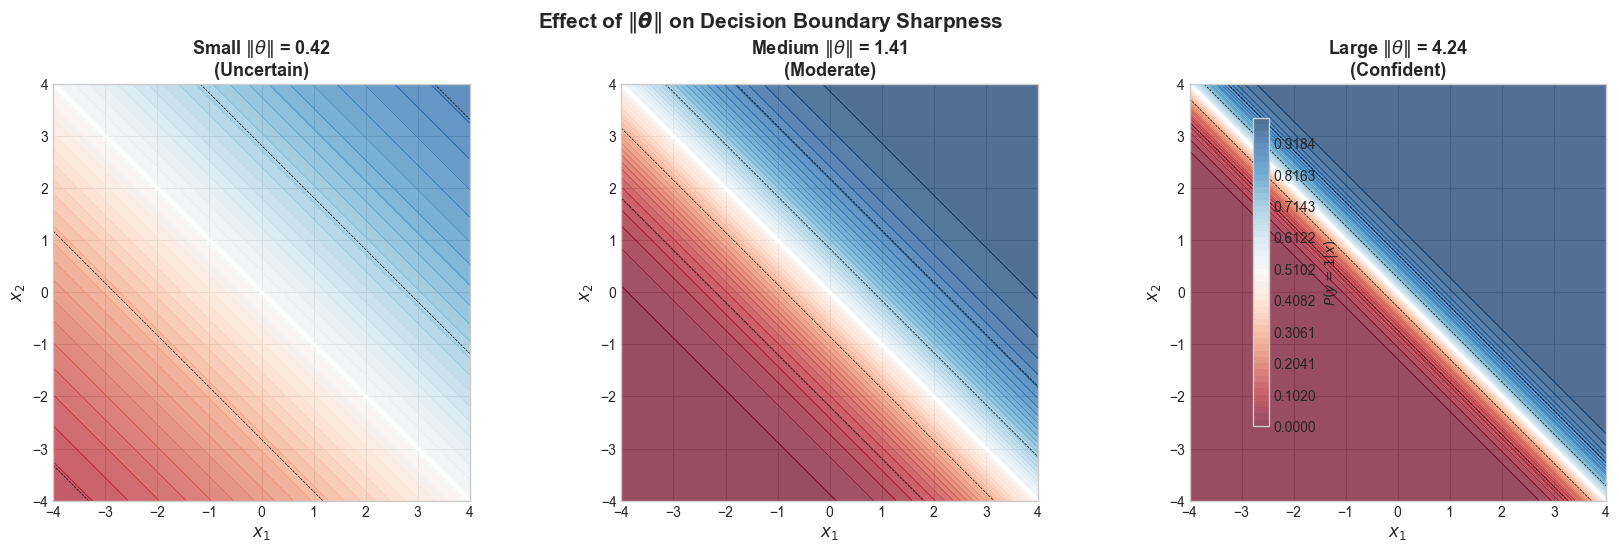

In [12]:
# Demonstrate θ magnitude effect on confidence
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
xx, yy = np.meshgrid(np.linspace(-4, 4, 300), np.linspace(-4, 4, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

for i, (scale_val, title) in enumerate([(0.3, 'Small $\\|\\theta\\|$ = 0.42\n(Uncertain)'),
                                         (1.0, 'Medium $\\|\\theta\\|$ = 1.41\n(Moderate)'),
                                         (3.0, 'Large $\\|\\theta\\|$ = 4.24\n(Confident)')]):
    theta = np.array([scale_val, scale_val])
    Z = sigmoid(grid @ theta).reshape(xx.shape)
    im = axes[i].contourf(xx, yy, Z, levels=np.linspace(0, 1, 50), cmap='RdBu', alpha=0.7)
    axes[i].contour(xx, yy, Z, levels=[0.5], colors='white', linewidths=2.5)
    axes[i].contour(xx, yy, Z, levels=[0.1, 0.3, 0.7, 0.9], colors='k',
                    linewidths=0.5, linestyles='--')
    axes[i].set_title(title, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('$x_1$', fontsize=12)
    axes[i].set_ylabel('$x_2$', fontsize=12)
    axes[i].set_aspect('equal')

plt.colorbar(im, ax=axes.tolist(), label='$P(y=1 | x)$', shrink=0.8)
plt.suptitle('Effect of $\\|\\boldsymbol{\\theta}\\|$ on Decision Boundary Sharpness',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<a id='evaluation'></a>
## 7. 📏 Model Evaluation

### Confusion Matrix

|  | **Predicted Positive** | **Predicted Negative** |
|--|------------------------|------------------------|
| **Actual Positive** | TP (True Positive) ✅ | FN (False Negative) ❌ |
| **Actual Negative** | FP (False Positive) ❌ | TN (True Negative) ✅ |

### Key Metrics

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **Accuracy** | $\frac{TP+TN}{TP+TN+FP+FN}$ | Overall correct (misleading for imbalanced data!) |
| **Precision** | $\frac{TP}{TP+FP}$ | Of predicted positives, how many truly are? |
| **Recall (Sensitivity)** | $\frac{TP}{TP+FN}$ | Of all true positives, how many did we catch? |
| **F1 Score** | $2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$ | Harmonic mean — balances precision & recall |
| **Specificity** | $\frac{TN}{TN+FP}$ | Of all true negatives, how many did we identify? |

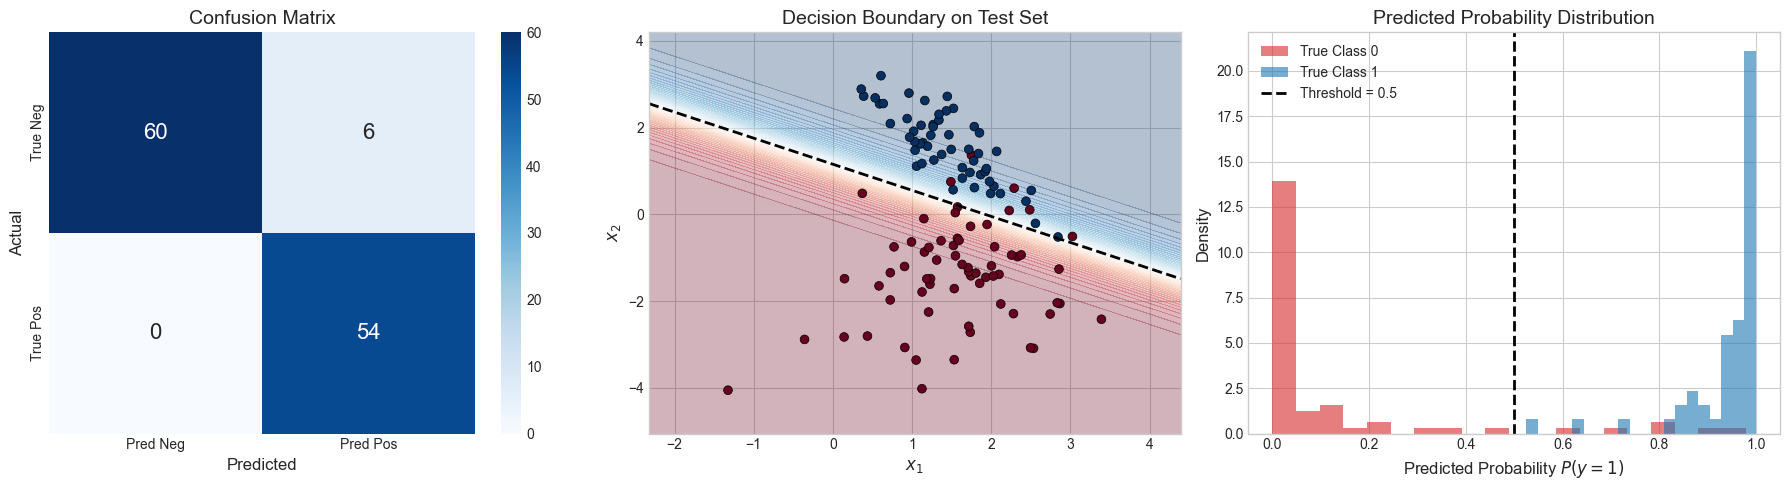


CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Class 0       1.00      0.91      0.95        66
     Class 1       0.90      1.00      0.95        54

    accuracy                           0.95       120
   macro avg       0.95      0.95      0.95       120
weighted avg       0.95      0.95      0.95       120



In [13]:
# Train a model and show comprehensive evaluation
np.random.seed(42)
X_eval, y_eval = make_classification(n_samples=400, n_features=2, n_redundant=0,
                                      n_informative=2, n_clusters_per_class=1,
                                      class_sep=1.5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_eval, y_eval, test_size=0.3, random_state=42)

# Fit sklearn model
clf = LogisticRegression(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

# Confusion matrix visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred Neg', 'Pred Pos'],
            yticklabels=['True Neg', 'True Pos'],
            annot_kws={'size': 16})
axes[0].set_title('Confusion Matrix', fontsize=14)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_xlabel('Predicted', fontsize=12)

# Panel 2: Decision boundary
plot_decision_boundary(X_test, y_test, lambda x: clf.predict_proba(x)[:, 1],
                       ax=axes[1], title='Decision Boundary on Test Set')

# Panel 3: Predicted probability distribution
axes[2].hist(y_prob[y_test == 0], bins=20, alpha=0.6, color=RED, label='True Class 0', density=True)
axes[2].hist(y_prob[y_test == 1], bins=20, alpha=0.6, color=BLUE, label='True Class 1', density=True)
axes[2].axvline(0.5, color='k', ls='--', lw=2, label='Threshold = 0.5')
axes[2].set_xlabel('Predicted Probability $P(y=1)$', fontsize=12)
axes[2].set_ylabel('Density', fontsize=12)
axes[2].set_title('Predicted Probability Distribution', fontsize=14)
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.show()

# Print classification report
print('\n' + '=' * 60)
print('CLASSIFICATION REPORT')
print('=' * 60)
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

### ROC Curve and AUC

**ROC** = Receiver Operating Characteristic

- Vary the classification threshold from 0 to 1
- At each threshold, compute TPR (True Positive Rate) and FPR (False Positive Rate)
- Plot TPR ($y$-axis) vs. FPR ($x$-axis)

**Interpreting AUC:**
| AUC Value | Interpretation |
|-----------|----------------|
| $= 1.0$ | Perfect classifier |
| $= 0.5$ | Random guessing (diagonal) |
| $< 0.5$ | Worse than random |

> AUC is **threshold-independent** — excellent for comparing models across different operating points.

In [14]:
# Interactive threshold selection with ROC and Precision-Recall curves
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_prob)


def plot_evaluation_interactive(threshold=0.5):
    y_pred_t = (y_prob >= threshold).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm_t.ravel()

    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    acc = (tp + tn) / (tp + tn + fp + fn)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

    # Panel 1: Confusion matrix at this threshold
    sns.heatmap(cm_t, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['True 0', 'True 1'],
                annot_kws={'size': 18})
    axes[0].set_title(f'Confusion Matrix (threshold = {threshold:.2f})', fontsize=13)
    axes[0].set_ylabel('Actual', fontsize=12)
    axes[0].set_xlabel('Predicted', fontsize=12)

    # Panel 2: ROC Curve with operating point
    axes[1].plot(fpr, tpr, c=BLUE, lw=2.5, label=f'ROC (AUC = {roc_auc:.3f})')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random (AUC = 0.5)')
    axes[1].fill_between(fpr, 0, tpr, alpha=0.1, color=BLUE)
    # Mark operating point
    fpr_t = fp / (fp + tn) if (fp + tn) > 0 else 0
    tpr_t = tp / (tp + fn) if (tp + fn) > 0 else 0
    axes[1].scatter([fpr_t], [tpr_t], c=ORANGE, s=200, zorder=5, edgecolors='k', linewidths=1.5)
    axes[1].annotate(f'({fpr_t:.2f}, {tpr_t:.2f})', xy=(fpr_t, tpr_t),
                     xytext=(fpr_t + 0.1, tpr_t - 0.1),
                     fontsize=11, fontweight='bold', color=ORANGE,
                     arrowprops=dict(arrowstyle='->', color=ORANGE))
    axes[1].set_xlabel('False Positive Rate (FPR)', fontsize=12)
    axes[1].set_ylabel('True Positive Rate (TPR)', fontsize=12)
    axes[1].set_title('ROC Curve', fontsize=14)
    axes[1].legend(fontsize=10)
    axes[1].set_xlim(-0.02, 1.02)
    axes[1].set_ylim(-0.02, 1.02)

    # Panel 3: Metrics summary
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'Specificity']
    values = [acc, prec, rec, f1, spec]
    colors_bar = [BLUE, GREEN, ORANGE, PURPLE, RED]
    bars = axes[2].barh(metrics, values, color=colors_bar, edgecolor='k', linewidth=0.5)
    for bar, val in zip(bars, values):
        axes[2].text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
                     f'{val:.3f}', va='center', fontsize=12, fontweight='bold')
    axes[2].set_xlim(0, 1.15)
    axes[2].set_xlabel('Score', fontsize=12)
    axes[2].set_title(f'Metrics at Threshold = {threshold:.2f}', fontsize=14)
    axes[2].axvline(0.5, color='gray', ls=':', lw=1)

    plt.tight_layout()
    plt.show()


interact(
    plot_evaluation_interactive,
    threshold=FloatSlider(value=0.5, min=0.01, max=0.99, step=0.01,
                          description='Threshold:',
                          style={'description_width': 'initial'}),
);

interactive(children=(FloatSlider(value=0.5, description='Threshold:', max=0.99, min=0.01, step=0.01, style=Sl…

<a id='regularization'></a>
## 8. 🛡️ Regularization

### General Form

$$
J_{\text{reg}}(\boldsymbol{\theta}, \theta_0) = J(\boldsymbol{\theta}, \theta_0) + \lambda\, R(\boldsymbol{\theta}) \qquad \text{where } \lambda > 0
$$

| Regularization | $R(\boldsymbol{\theta})$ | Effect |
|----------------|--------------------------|--------|
| **L2 (Ridge)** | $\|\boldsymbol{\theta}\|_2^2 = \sum_j \theta_j^2$ | Shrinks all weights toward zero; distributes weight among correlated features |
| **L1 (Lasso)** | $\|\boldsymbol{\theta}\|_1 = \sum_j |\theta_j|$ | Drives some weights **exactly to zero**; automatic **feature selection** |

### Geometry
- **L2 constraint** region is a **circle** (sphere in higher dimensions) → smooth shrinkage
- **L1 constraint** region is a **diamond** → corners promote sparsity (exact zeros)

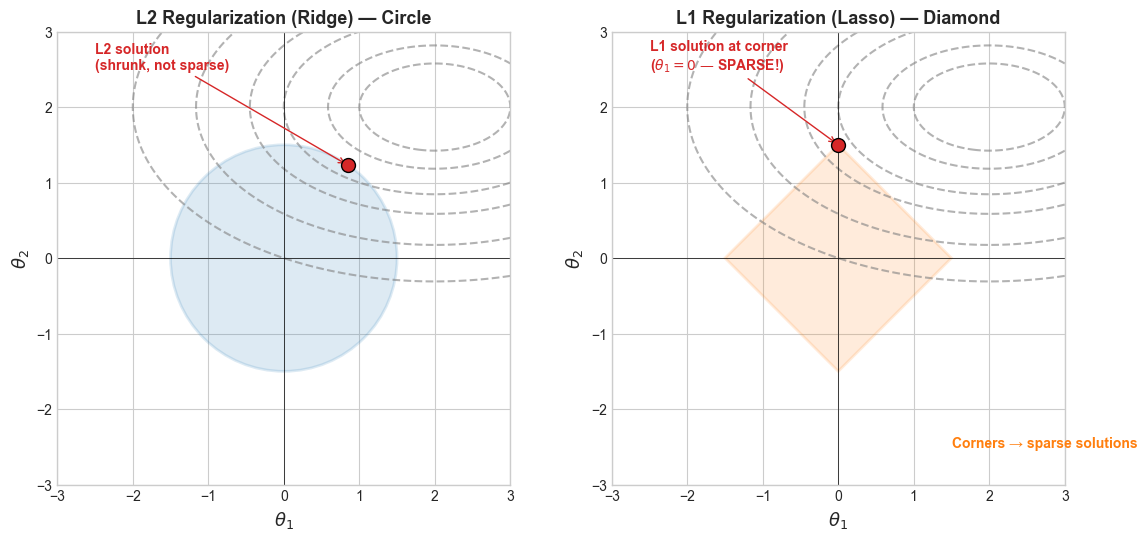

In [15]:
# Visualize L1 vs L2 constraint regions and their effect
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

# --- L2 constraint (circle) ---
ax = axes[0]
circle = plt.Circle((0, 0), 1.5, fill=True, color=BLUE, alpha=0.15, linewidth=2, edgecolor=BLUE)
ax.add_patch(circle)

# Loss contour ellipses (offset from origin)
theta_grid = np.linspace(-3, 3, 300)
T1, T2 = np.meshgrid(theta_grid, theta_grid)
# Simulate elliptical loss contours centered at (2, 2)
loss_contour = 0.5 * (T1 - 2) ** 2 + 1.5 * (T2 - 2) ** 2
ax.contour(T1, T2, loss_contour, levels=[0.5, 1, 2, 3, 5, 8], colors='gray', linestyles='--', alpha=0.6)

# Find intersection (tangent point of ellipse and circle)
ax.scatter([0.85], [1.23], c=RED, s=100, zorder=5, edgecolors='k')
ax.annotate('L2 solution\n(shrunk, not sparse)', xy=(0.85, 1.23),
            xytext=(-2.5, 2.5), fontsize=10, fontweight='bold', color=RED,
            arrowprops=dict(arrowstyle='->', color=RED))

ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel('$\\theta_1$', fontsize=13)
ax.set_ylabel('$\\theta_2$', fontsize=13)
ax.set_title('L2 Regularization (Ridge) — Circle', fontsize=13, fontweight='bold')
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect('equal')

# --- L1 constraint (diamond) ---
ax = axes[1]
diamond = plt.Polygon([(0, 1.5), (1.5, 0), (0, -1.5), (-1.5, 0)],
                       fill=True, color=ORANGE, alpha=0.15, linewidth=2, edgecolor=ORANGE)
ax.add_patch(diamond)

ax.contour(T1, T2, loss_contour, levels=[0.5, 1, 2, 3, 5, 8], colors='gray', linestyles='--', alpha=0.6)

# L1 solution at corner (sparse!)
ax.scatter([0], [1.5], c=RED, s=100, zorder=5, edgecolors='k')
ax.annotate('L1 solution at corner\n($\\theta_1 = 0$ — SPARSE!)', xy=(0, 1.5),
            xytext=(-2.5, 2.5), fontsize=10, fontweight='bold', color=RED,
            arrowprops=dict(arrowstyle='->', color=RED))

ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel('$\\theta_1$', fontsize=13)
ax.set_ylabel('$\\theta_2$', fontsize=13)
ax.set_title('L1 Regularization (Lasso) — Diamond', fontsize=13, fontweight='bold')
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect('equal')
ax.text(1.5, -2.5, 'Corners → sparse solutions', fontsize=10, color=ORANGE, fontweight='bold')

plt.tight_layout()
plt.show()

In [19]:
# Interactive regularization comparison
np.random.seed(42)
X_reg, y_reg = make_classification(n_samples=300, n_features=2, n_redundant=0,
                                    n_informative=2, n_clusters_per_class=1,
                                    class_sep=1.2, random_state=42)
scaler_reg = StandardScaler()
X_reg_sc = scaler_reg.fit_transform(X_reg)
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg_sc, y_reg, test_size=0.3, random_state=42
)


def plot_regularization(log_lambda=-1.0, penalty='l2'):
    lam = 10 ** log_lambda
    C_val = 1.0 / lam  # sklearn uses C = 1/lambda

    clf_r = LogisticRegression(C=C_val, penalty=penalty, solver='saga',
                                max_iter=5000, random_state=42)
    clf_r.fit(X_reg_train, y_reg_train)

    y_pred_r = clf_r.predict(X_reg_test)
    y_prob_r = clf_r.predict_proba(X_reg_test)[:, 1]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

    # Panel 1: Decision boundary
    plot_decision_boundary(X_reg_sc, y_reg, lambda x: clf_r.predict_proba(x)[:, 1],
                           ax=axes[0],
                           title=f'Decision Boundary ({penalty.upper()}, λ={lam:.4f})')

    # Panel 2: Weight visualization
    weights = clf_r.coef_[0]
    labels = [f'$\\theta_{{{j+1}}}$' for j in range(len(weights))]
    colors_w = [BLUE if w >= 0 else RED for w in weights]
    axes[1].barh(labels, weights, color=colors_w, edgecolor='k', linewidth=0.5)
    axes[1].axvline(0, color='k', lw=1)
    axes[1].set_xlabel('Weight Value', fontsize=12)
    axes[1].set_title(f'Learned Weights ($\\|\\theta\\| = {np.linalg.norm(weights):.3f}$)', fontsize=13)
    for j, w in enumerate(weights):
        axes[1].text(w + 0.05 * np.sign(w), j, f'{w:.3f}', va='center', fontsize=12, fontweight='bold')

    # Panel 3: Metrics
    fpr_r, tpr_r, _ = roc_curve(y_reg_test, y_prob_r)
    auc_r = auc(fpr_r, tpr_r)
    acc_r = accuracy_score(y_reg_test, y_pred_r)
    f1_r = f1_score(y_reg_test, y_pred_r)

    axes[2].plot(fpr_r, tpr_r, c=BLUE, lw=2.5, label=f'AUC = {auc_r:.3f}')
    axes[2].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    axes[2].fill_between(fpr_r, 0, tpr_r, alpha=0.1, color=BLUE)
    axes[2].set_xlabel('FPR', fontsize=12)
    axes[2].set_ylabel('TPR', fontsize=12)
    axes[2].set_title(f'ROC Curve (Acc={acc_r:.3f}, F1={f1_r:.3f})', fontsize=13)
    axes[2].legend(fontsize=11)

    plt.tight_layout()
    plt.show()


interact(
    plot_regularization,
    log_lambda=FloatSlider(value=-1.0, min=-4.0, max=2.0, step=0.1,
                           description='log₁₀(λ):',
                           style={'description_width': 'initial'}),
    penalty=Dropdown(options=['l1', 'l2'], value='l2', description='Penalty:',
                     style={'description_width': 'initial'}),
);

interactive(children=(FloatSlider(value=-1.0, description='log₁₀(λ):', max=2.0, min=-4.0, style=SliderStyle(de…

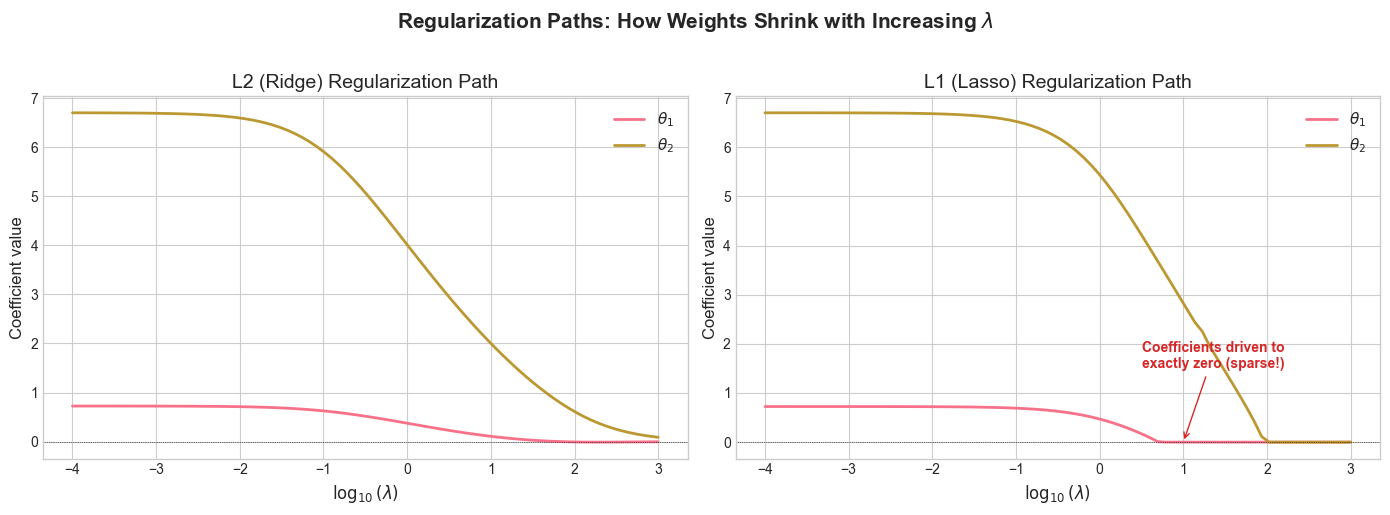

In [17]:
# Regularization path — show how weights change with lambda
lambdas = np.logspace(-4, 3, 80)
coefs_l1 = []
coefs_l2 = []

for lam in lambdas:
    clf_l2 = LogisticRegression(C=1/lam, penalty='l2', solver='saga', max_iter=5000, random_state=42)
    clf_l1 = LogisticRegression(C=1/lam, penalty='l1', solver='saga', max_iter=5000, random_state=42)
    clf_l2.fit(X_reg_train, y_reg_train)
    clf_l1.fit(X_reg_train, y_reg_train)
    coefs_l2.append(clf_l2.coef_[0].copy())
    coefs_l1.append(clf_l1.coef_[0].copy())

coefs_l2 = np.array(coefs_l2)
coefs_l1 = np.array(coefs_l1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for j in range(coefs_l2.shape[1]):
    axes[0].plot(np.log10(lambdas), coefs_l2[:, j], lw=2, label=f'$\\theta_{{{j+1}}}$')
axes[0].axhline(0, color='k', ls=':', lw=0.5)
axes[0].set_xlabel('$\\log_{10}(\\lambda)$', fontsize=12)
axes[0].set_ylabel('Coefficient value', fontsize=12)
axes[0].set_title('L2 (Ridge) Regularization Path', fontsize=14)
axes[0].legend(fontsize=11)

for j in range(coefs_l1.shape[1]):
    axes[1].plot(np.log10(lambdas), coefs_l1[:, j], lw=2, label=f'$\\theta_{{{j+1}}}$')
axes[1].axhline(0, color='k', ls=':', lw=0.5)
axes[1].set_xlabel('$\\log_{10}(\\lambda)$', fontsize=12)
axes[1].set_ylabel('Coefficient value', fontsize=12)
axes[1].set_title('L1 (Lasso) Regularization Path', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].annotate('Coefficients driven to\nexactly zero (sparse!)', xy=(1, 0),
                 xytext=(0.5, 1.5), fontsize=10, color=RED, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color=RED))

plt.suptitle('Regularization Paths: How Weights Shrink with Increasing $\\lambda$',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<a id='multiclass'></a>
## 9. 🔀 Multiclass Logistic Regression

### One-vs-Rest (OvR)
- Train $K$ separate binary classifiers
- Classifier $k$: class $k$ vs. all others
- Predict class with highest confidence

### Softmax (Multinomial)

Direct generalization to $K$ classes:

$$
P(y=k \mid \boldsymbol{x}) = \frac{e^{\boldsymbol{\theta}_k^\top \boldsymbol{x}}}{\sum_{j=1}^{K} e^{\boldsymbol{\theta}_j^\top \boldsymbol{x}}}
$$

- All $K$ probabilities sum to 1
- Loss: **categorical cross-entropy**
- Preferred when classes are **mutually exclusive**

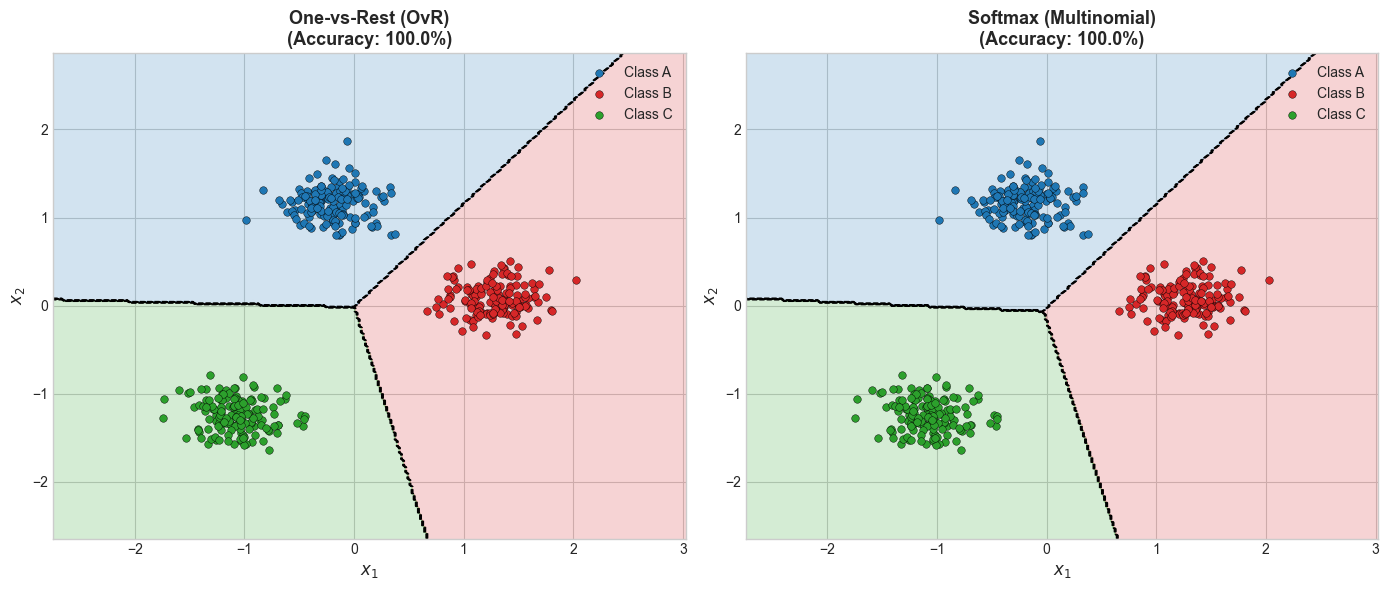

In [20]:
# Multiclass demonstration: OvR vs Softmax
np.random.seed(42)
from sklearn.datasets import make_blobs
from sklearn.multiclass import OneVsRestClassifier

X_multi, y_multi = make_blobs(n_samples=450, n_features=2, centers=3,
                               cluster_std=1.2, random_state=42)
scaler_multi = StandardScaler()
X_multi_sc = scaler_multi.fit_transform(X_multi)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Build two classifiers: OvR wrapper and default (multinomial)
classifiers = [
    ('One-vs-Rest (OvR)', OneVsRestClassifier(LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42))),
    ('Softmax (Multinomial)', LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)),
]

for ax, (title, clf_mc) in zip(axes, classifiers):
    clf_mc.fit(X_multi_sc, y_multi)

    # Decision regions
    xx, yy = np.meshgrid(np.linspace(X_multi_sc[:, 0].min() - 1, X_multi_sc[:, 0].max() + 1, 300),
                         np.linspace(X_multi_sc[:, 1].min() - 1, X_multi_sc[:, 1].max() + 1, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = clf_mc.predict(grid).reshape(xx.shape)

    cmap = mcolors.ListedColormap([BLUE, RED, GREEN])
    ax.contourf(xx, yy, Z, alpha=0.2, cmap=cmap)
    ax.contour(xx, yy, Z, colors='k', linewidths=1, linestyles='--')

    for cls, color, label in zip([0, 1, 2], [BLUE, RED, GREEN], ['A', 'B', 'C']):
        mask = y_multi == cls
        ax.scatter(X_multi_sc[mask, 0], X_multi_sc[mask, 1], c=color, s=30,
                   edgecolors='k', linewidths=0.3, label=f'Class {label}')

    acc_mc = accuracy_score(y_multi, clf_mc.predict(X_multi_sc))
    ax.set_title(f'{title}\n(Accuracy: {acc_mc:.1%})', fontsize=13, fontweight='bold')
    ax.set_xlabel('$x_1$', fontsize=12)
    ax.set_ylabel('$x_2$', fontsize=12)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

In [21]:
# Interactive: Softmax probability visualization for 3 classes
clf_softmax = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
clf_softmax.fit(X_multi_sc, y_multi)


def plot_softmax_proba(x1=0.0, x2=0.0):
    point = np.array([[x1, x2]])
    probs = clf_softmax.predict_proba(point)[0]
    pred = clf_softmax.predict(point)[0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    # Left: scatter with query point
    ax = axes[0]
    for cls, color, label in zip([0, 1, 2], [BLUE, RED, GREEN], ['A', 'B', 'C']):
        mask = y_multi == cls
        ax.scatter(X_multi_sc[mask, 0], X_multi_sc[mask, 1], c=color, s=30,
                   edgecolors='k', linewidths=0.3, label=f'Class {label}', alpha=0.6)
    ax.scatter([x1], [x2], c=ORANGE, s=300, marker='*', zorder=5, edgecolors='k', linewidths=1.5)
    ax.annotate(f'Predicted: Class {["A", "B", "C"][pred]}', xy=(x1, x2),
                xytext=(x1 + 0.5, x2 + 0.5),
                fontsize=12, fontweight='bold', color=ORANGE,
                arrowprops=dict(arrowstyle='->', color=ORANGE, lw=2))
    ax.set_xlabel('$x_1$', fontsize=12)
    ax.set_ylabel('$x_2$', fontsize=12)
    ax.set_title('Query Point in Feature Space', fontsize=14)
    ax.legend(fontsize=10)

    # Right: probability bar chart
    ax = axes[1]
    bars = ax.bar(['Class A', 'Class B', 'Class C'], probs, color=[BLUE, RED, GREEN],
                  edgecolor='k', linewidth=0.5)
    for bar, p in zip(bars, probs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f'{p:.3f}', ha='center', fontsize=14, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Probability', fontsize=12)
    ax.set_title('Softmax Probabilities (sum = 1)', fontsize=14)
    ax.axhline(1/3, color='gray', ls=':', lw=1, label='Random (1/3)')
    ax.legend(fontsize=10)

    plt.tight_layout()
    plt.show()


interact(
    plot_softmax_proba,
    x1=FloatSlider(value=0.0, min=-4.0, max=4.0, step=0.1, description='$x_1$:',
                   style={'description_width': 'initial'}),
    x2=FloatSlider(value=0.0, min=-4.0, max=4.0, step=0.1, description='$x_2$:',
                   style={'description_width': 'initial'}),
);

interactive(children=(FloatSlider(value=0.0, description='$x_1$:', max=4.0, min=-4.0, style=SliderStyle(descri…

<a id='nonlinear'></a>
## 10. 🌀 Nonlinear Decision Boundaries via Feature Engineering

Logistic regression is **linear** in feature space, but we can create nonlinear boundaries by **lifting** the features:

$$
\boldsymbol{\phi}(\boldsymbol{x}) = [x_1, x_2, x_1^2, x_1 x_2, x_2^2]^\top
$$

- Degree 2 ⇒ **conic sections** (circles, ellipses, hyperbolas)
- Degree $d$ ⇒ $\binom{p+d}{d}$ features
- **Risk of overfitting** at high $d$ — use **regularization**!

> ⚠️ **Linear transforms ≠ nonlinearity:** PCA scores, PLSR latent variables, and ICA components are **linear** projections of $\mathbf{X}$. Using them as inputs still yields a **linear** boundary in the original space.

In [22]:
# Interactive: nonlinear boundaries with polynomial features
np.random.seed(42)
X_circ, y_circ = make_circles(n_samples=400, noise=0.15, factor=0.5, random_state=42)
X_moon, y_moon = make_moons(n_samples=400, noise=0.2, random_state=42)


def plot_nonlinear_boundary(degree=1, dataset='circles', log_C=0.0):
    C_val = 10 ** log_C
    X_data = X_circ if dataset == 'circles' else X_moon
    y_data = y_circ if dataset == 'circles' else y_moon

    # Apply polynomial feature transform
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(X_data)
    scaler = StandardScaler()
    X_poly_sc = scaler.fit_transform(X_poly)

    clf_nl = LogisticRegression(C=C_val, max_iter=5000, random_state=42)
    clf_nl.fit(X_poly_sc, y_data)

    # Predict on original 2D grid
    def predict_on_grid(grid_2d):
        grid_poly = poly.transform(grid_2d)
        grid_sc = scaler.transform(grid_poly)
        return clf_nl.predict_proba(grid_sc)[:, 1]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Left: Linear (degree 1) for comparison
    clf_lin = LogisticRegression(C=C_val, max_iter=5000, random_state=42)
    scaler_lin = StandardScaler()
    X_data_sc = scaler_lin.fit_transform(X_data)
    clf_lin.fit(X_data_sc, y_data)
    acc_lin = accuracy_score(y_data, clf_lin.predict(X_data_sc))
    plot_decision_boundary(X_data, y_data,
                           lambda x: clf_lin.predict_proba(scaler_lin.transform(x))[:, 1],
                           ax=axes[0], title=f'Linear (degree=1)\nAccuracy: {acc_lin:.1%}')

    # Right: Polynomial
    acc_poly = accuracy_score(y_data, clf_nl.predict(X_poly_sc))
    n_features = X_poly.shape[1]
    plot_decision_boundary(X_data, y_data, predict_on_grid,
                           ax=axes[1],
                           title=f'Polynomial (degree={degree}, {n_features} features)\nAccuracy: {acc_poly:.1%}')

    plt.suptitle(f'Dataset: {dataset.capitalize()} │ C = {C_val:.2f}',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


interact(
    plot_nonlinear_boundary,
    degree=IntSlider(value=1, min=1, max=6, step=1, description='Poly degree:',
                     style={'description_width': 'initial'}),
    dataset=Dropdown(options=['circles', 'moons'], value='circles', description='Dataset:',
                     style={'description_width': 'initial'}),
    log_C=FloatSlider(value=0.0, min=-2.0, max=4.0, step=0.2, description='log₁₀(C):',
                      style={'description_width': 'initial'}),
);

interactive(children=(IntSlider(value=1, description='Poly degree:', max=6, min=1, style=SliderStyle(descripti…

<a id='summary'></a>
## 11. 📝 Summary & Key Takeaways

### Where Does Logistic Regression Fit?

| Method | Type | Supervised? | Outputs | Key Idea |
|--------|------|-------------|---------|----------|
| Linear Reg. | Regression | Yes | Continuous $\hat{y}$ | Min. MSE |
| **Logistic Reg.** | **Classification** | **Yes** | **Probabilities** | **Max. likelihood** |
| PCA | Dim. Reduction | No | Components | Max. variance |
| PLSR | Regression | Yes | Continuous $\hat{y}$ | Max. covariance |
| t-SNE | Visualization | No | 2D/3D map | Preserve local structure |
| ICA | Source Sep. | No | Indep. sources | Max. independence |

> **Typical Pipeline:** Data → PCA/PLSR → Logistic Regression → ROC/AUC

---

### Key Takeaways

1. Logistic regression applies $\sigma(\boldsymbol{\theta}^\top\boldsymbol{x} + \theta_0)$ to map linear combinations to **probabilities**
2. The loss function (binary cross-entropy) comes directly from **MLE with Bernoulli data**
3. No closed-form solution, but **convexity** guarantees convergence of gradient descent
4. The decision boundary $\boldsymbol{\theta}^\top\boldsymbol{x} + \theta_0 = 0$ is a **hyperplane** — linear in feature space
5. **Regularization** (L1/L2) prevents overfitting and handles perfect separability
6. Evaluation: use precision, recall, F1, **ROC/AUC** — not just accuracy
7. Multiclass via One-vs-Rest or **Softmax**
8. Feature engineering extends to nonlinear boundaries

### Practical Considerations

| Topic | Recommendation |
|-------|----------------|
| **Feature Scaling** | Standardize features (zero mean, unit variance) before fitting. Gradient descent converges much faster with scaled features. |
| **Imbalanced Data** | Use `class_weight='balanced'`, consider SMOTE oversampling, or adjust decision threshold via ROC |
| **Multicollinearity** | L2 regularization handles moderate multicollinearity. For severe cases: use PCA or PLSR first |
| **Convergence** | If classes are perfectly separable, $\boldsymbol{\theta} \to \pm\infty$. Regularization prevents this. Always check convergence warnings! |

In [ ]:
# Final comprehensive demo: end-to-end logistic regression pipeline
print('=' * 70)
print('   COMPLETE LOGISTIC REGRESSION PIPELINE DEMO')
print('=' * 70)

# 1. Generate data
np.random.seed(42)
X_final, y_final = make_classification(n_samples=500, n_features=5, n_redundant=1,
                                        n_informative=3, n_clusters_per_class=1,
                                        class_sep=1.0, random_state=42)
feature_names = [f'Feature {i+1}' for i in range(X_final.shape[1])]

# 2. Train-test split
X_tr, X_te, y_tr, y_te = train_test_split(X_final, y_final, test_size=0.3, random_state=42)
print(f'\n📊 Data: {X_tr.shape[0]} train, {X_te.shape[0]} test, {X_final.shape[1]} features')

# 3. Feature scaling
scaler_final = StandardScaler()
X_tr_sc = scaler_final.fit_transform(X_tr)
X_te_sc = scaler_final.transform(X_te)
print('✅ Features standardized')

# 4. Fit model with L2 regularization
clf_final = LogisticRegression(C=1.0, penalty='l2', random_state=42, max_iter=1000)
clf_final.fit(X_tr_sc, y_tr)
print('✅ Model fitted with L2 regularization (C=1.0)')

# 5. Evaluate
y_pred_final = clf_final.predict(X_te_sc)
y_prob_final = clf_final.predict_proba(X_te_sc)[:, 1]

print('\n' + '─' * 70)
print(classification_report(y_te, y_pred_final, target_names=['Class 0', 'Class 1']))

# 6. Plot results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
cm_final = confusion_matrix(y_te, y_pred_final)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'],
            annot_kws={'size': 16})
axes[0].set_title('Confusion Matrix', fontsize=14)

# ROC curve
fpr_final, tpr_final, _ = roc_curve(y_te, y_prob_final)
auc_final = auc(fpr_final, tpr_final)
axes[1].plot(fpr_final, tpr_final, c=BLUE, lw=2.5, label=f'AUC = {auc_final:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
axes[1].fill_between(fpr_final, 0, tpr_final, alpha=0.1, color=BLUE)
axes[1].set_xlabel('FPR', fontsize=12)
axes[1].set_ylabel('TPR', fontsize=12)
axes[1].set_title('ROC Curve', fontsize=14)
axes[1].legend(fontsize=12)

# Feature importance
coefs = clf_final.coef_[0]
sorted_idx = np.argsort(np.abs(coefs))
colors_imp = [GREEN if c > 0 else RED for c in coefs[sorted_idx]]
axes[2].barh([feature_names[i] for i in sorted_idx], np.abs(coefs[sorted_idx]),
             color=colors_imp, edgecolor='k', linewidth=0.5)
axes[2].set_xlabel('|Coefficient|', fontsize=12)
axes[2].set_title('Feature Importance (|θ|)', fontsize=14)
for j, idx in enumerate(sorted_idx):
    axes[2].text(np.abs(coefs[idx]) + 0.02, j, f'{coefs[idx]:+.3f}',
                va='center', fontsize=10)

plt.tight_layout()
plt.show()

print_box('Pipeline Complete',
          f'Accuracy: {accuracy_score(y_te, y_pred_final):.1%}\n'
          f'AUC:      {auc_final:.3f}\n'
          f'F1 Score: {f1_score(y_te, y_pred_final):.3f}', 'green')

---

*Notebook by **Adil Rasheed** — Department of Engineering Cybernetics, NTNU*  
*TTK4260: Multivariate Data Analysis & Machine Learning — Spring 2026*